# Clustering Comparison: Breast Cancer Wisconsin (Diagnostic)

Dataset: [`uciml/breast-cancer-wisconsin-data`](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)
(569 samples, 30 continuous features from digitized FNA images of breast masses).
Ground truth is the binary diagnosis: `0` Benign (357), `1` Malignant (212).

The same six algorithms as the Wine notebook, with `k=2`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sc4020 import data, clustering, metrics, viz

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
RESULTS_DIR = Path("..") / "results"

METRIC_COLS = [
    "method", "fit_seconds", "n_clusters_found", "noise_points",
    "silhouette", "davies_bouldin", "adjusted_rand_index",
]

## Load and standardize

The tracking columns `id` and `Unnamed: 32` are dropped, `diagnosis` becomes the ground truth
(`B→0`, `M→1`) and the 30 remaining features are standardized.

In [2]:
ds = data.load_breast_cancer_data()
print(f"{ds.name}: X={ds.X.shape}, classes={ds.class_names}, n_true_clusters={ds.n_true_clusters}")
print(pd.Series(ds.y).map(dict(enumerate(ds.class_names))).value_counts())

breast_cancer: X=(569, 30), classes=['Benign', 'Malignant'], n_true_clusters=2
Benign       357
Malignant    212
Name: count, dtype: int64


## 2D embedding for visualization

Clustering runs on the full standardized 30-D space; PCA to 2D is *only* used to plot.

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(ds.X)
var_ratio = pca.explained_variance_ratio_ * 100
print(f"PC1 {var_ratio[0]:.1f}% + PC2 {var_ratio[1]:.1f}% = {var_ratio.sum():.1f}% of variance")

PC1 44.3% + PC2 19.0% = 63.2% of variance


## Fit 6 clustering models

* **Distance-based:** K-Means (k=2)
* **Hierarchical:** Agglomerative (k=2, Ward linkage)
* **Probabilistic:** Gaussian Mixture (k=2)
* **Graph-based:** Spectral (k=2, nearest-neighbors affinity)
* **Density-based:** DBSCAN (eps=4.5, min_samples=5)
* **Exemplar-based:** Affinity Propagation (damping=0.9, preference=-150)

In [4]:
results = clustering.run_models(clustering.breast_cancer_models(), ds.X)
for name, r in results.items():
    print(f"{name:22s} fit_seconds={r.fit_seconds:.3f}")

K-Means (k=2)          fit_seconds=1.426
Agglomerative (k=2)    fit_seconds=0.025
GMM (k=2)              fit_seconds=0.012
Spectral (k=2)         fit_seconds=0.047
DBSCAN (eps=4.5)       fit_seconds=0.005
Affinity Propagation   fit_seconds=0.073


## Metrics

In [5]:
results_df = metrics.build_results_table(ds.name, ds.X, results, ds.y)
display(results_df[METRIC_COLS].round(4))
results_df.to_csv(RESULTS_DIR / "breast_cancer_results.csv", index=False)

,method,fit_seconds,n_clusters_found,noise_points,silhouette,davies_bouldin,adjusted_rand_index
0,K-Means (k=2),1.4260,2,0,0.3434,1.3205,0.6536
1,Agglomerative (k=2),0.0249,2,0,0.3394,1.3700,0.5750
2,GMM (k=2),0.0122,2,0,0.3145,1.3770,0.7740
3,Spectral (k=2),0.0473,2,0,0.3367,1.3161,0.7608
4,DBSCAN (eps=4.5),0.0045,1,32,NaN,NaN,0.0260
5,Affinity Propagation,0.0733,16,0,0.0935,1.5665,0.1218


## Cluster visualizations vs. ground truth

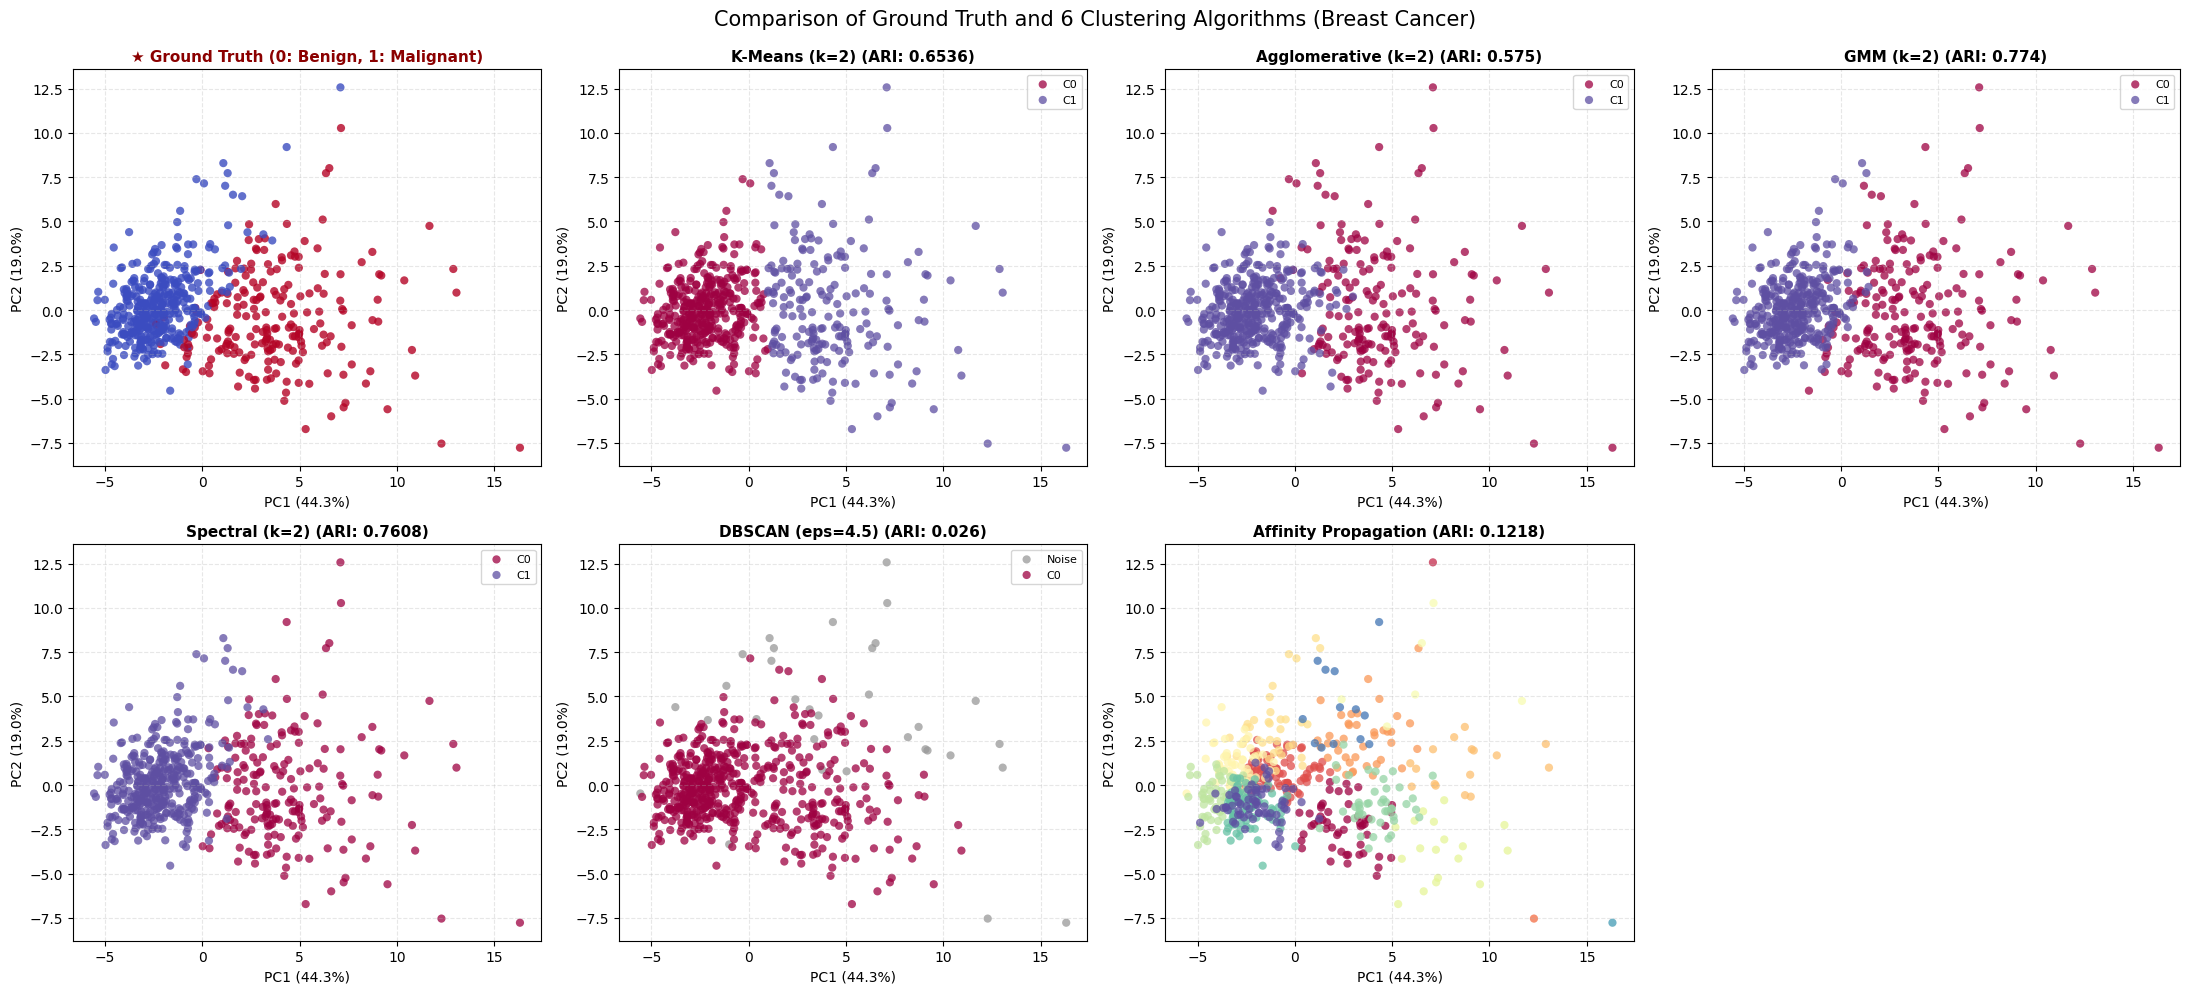

In [6]:
ari = dict(zip(results_df["method"], results_df["adjusted_rand_index"].round(4)))
viz.plot_pca_grid(
    X_2d, results, y_true=ds.y, var_ratio=var_ratio, ari=ari,
    gt_title="★ Ground Truth (0: Benign, 1: Malignant)",
    title="Comparison of Ground Truth and 6 Clustering Algorithms (Breast Cancer)",
    gt_cmap="coolwarm", cmap=plt.cm.Spectral, edgecolors="none", size=35,
)
plt.show()

## Discussion

* **GMM (ARI ≈ 0.77) and Spectral (≈ 0.76) are best:** benign and malignant cells form two
  distributions with different spreads, which GMM's per-cluster covariance and the
  nearest-neighbors graph capture better than K-Means (≈ 0.65).
* **Agglomerative (Ward, ≈ 0.58):** minimizing within-cluster variance mirrors K-Means but
  is less accurate here.
* **Curse of dimensionality in DBSCAN:** in 30-D, pairwise Euclidean distances become sparse.
  A single global ε either collapses everything into one cluster or discards the dispersed
  malignant points as noise (`-1`).
* **Affinity Propagation:** without a fixed cluster count, message passing finds many local
  sub-densities and over-fragments the two diagnostic classes.